# 04 — Evaluation: SHAP Analysis, Error Analysis & Model Comparison

**TFM: Demand Forecasting for Inventory Management Using Machine Learning**

Author: Ona Mas i Serra

This notebook performs SHAP feature importance analysis on the best model (LightGBM),
detailed error analysis across models, per-product RMSE distributions,
and promo vs non-promo performance comparison.


## Setup & Configuration


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import shap
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
from style_config import (apply_style, PRIMARY, SECONDARY, NEUTRAL, ALERT,
                          get_model_color, get_model_colors)

%matplotlib inline

BASE_DIR = Path(".")
FEATURES_PATH = BASE_DIR / 'output' / 'processed' / 'features.parquet'
PREDS_PATH = BASE_DIR / 'output' / 'models' / 'predictions_all_models.parquet'
ARIMA_PATH = BASE_DIR / 'output' / 'models' / 'arima_predictions.parquet'
PARAMS_PATH = BASE_DIR / 'output' / 'models' / 'tuned_params.json'
OUTPUT_DIR = BASE_DIR / 'output' / 'evaluation'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

apply_style()

TARGET = 'udsVenta'
EXCLUDE = ['producto', 'idSecuencia', 'fecha', 'day_name', TARGET,
           'prod_mean_sales', 'prod_std_sales', 'prod_median_sales']

def save_fig(name):
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'{name}.png', bbox_inches='tight', dpi=120)
    plt.show()
    print(f'   \u2192 Saved {name}.png')

def calc_metrics(y_true, y_pred):
    y_true, y_pred = np.array(y_true, dtype=float), np.array(y_pred, dtype=float)
    errors = y_true - y_pred
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true > 0
    mape = np.mean(np.abs(errors[mask] / y_true[mask])) * 100 if mask.sum() > 0 else np.nan
    sigma_e = np.std(errors)
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'sigma_e': sigma_e}


## 1. Load Data & Retrain LightGBM

Load the feature-engineered data and predictions from the modelling step,
then retrain LightGBM on the train split for SHAP analysis.


In [2]:
print('=' * 60)
print('1. LOADING DATA & RETRAINING LightGBM')
print('=' * 60)

df = pd.read_parquet(FEATURES_PATH)
preds = pd.read_parquet(PREDS_PATH)
arima_preds = pd.read_parquet(ARIMA_PATH)
preds = preds.merge(arima_preds[['producto', 'fecha', 'ARIMA']], on=['producto', 'fecha'], how='left')
with open(PARAMS_PATH) as f:
    params = json.load(f)

feature_cols = [c for c in df.columns if c not in EXCLUDE]

all_dates = sorted(df['fecha'].unique())
cutoff = all_dates[-30]
train = df[df['fecha'] < cutoff]
test = df[df['fecha'] >= cutoff]

X_train, y_train = train[feature_cols], train[TARGET]
X_test, y_test = test[feature_cols], test[TARGET]

lgb_params = params['lgb']
model = lgb.LGBMRegressor(**lgb_params)
model.fit(X_train, y_train)
print(f'Train: {len(train):,} | Test: {len(test):,}')


1. LOADING DATA & RETRAINING LightGBM


Train: 579,453 | Test: 25,830


## 2. SHAP Feature Importance

Compute SHAP values using TreeExplainer on a sample of the test set.
Generate beeswarm summary, bar plot, importance table, and dependence plots for top 4 features.



2. SHAP FEATURE IMPORTANCE


Generating SHAP summary plot...


/var/folders/n_/9zp1khbj0j7_b4xf1q304vvh0000gq/T/ipykernel_7320/1181906898.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, show=False, max_display=20)


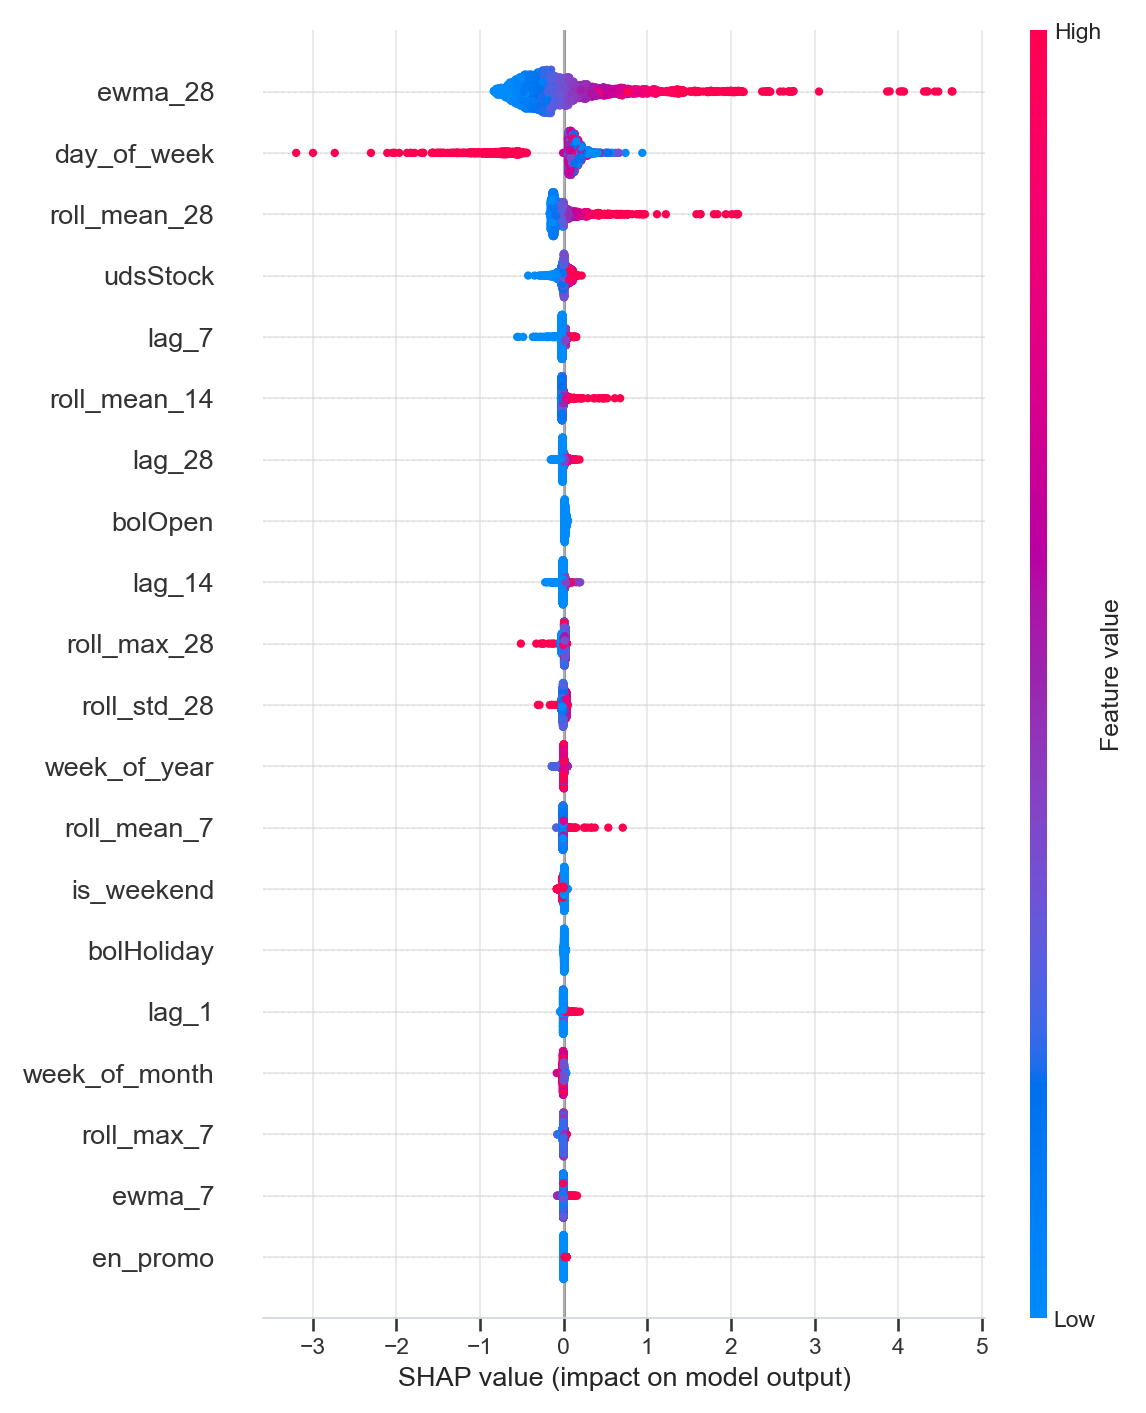

   → Saved 14_shap_summary.png


/var/folders/n_/9zp1khbj0j7_b4xf1q304vvh0000gq/T/ipykernel_7320/1181906898.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False, max_display=20,


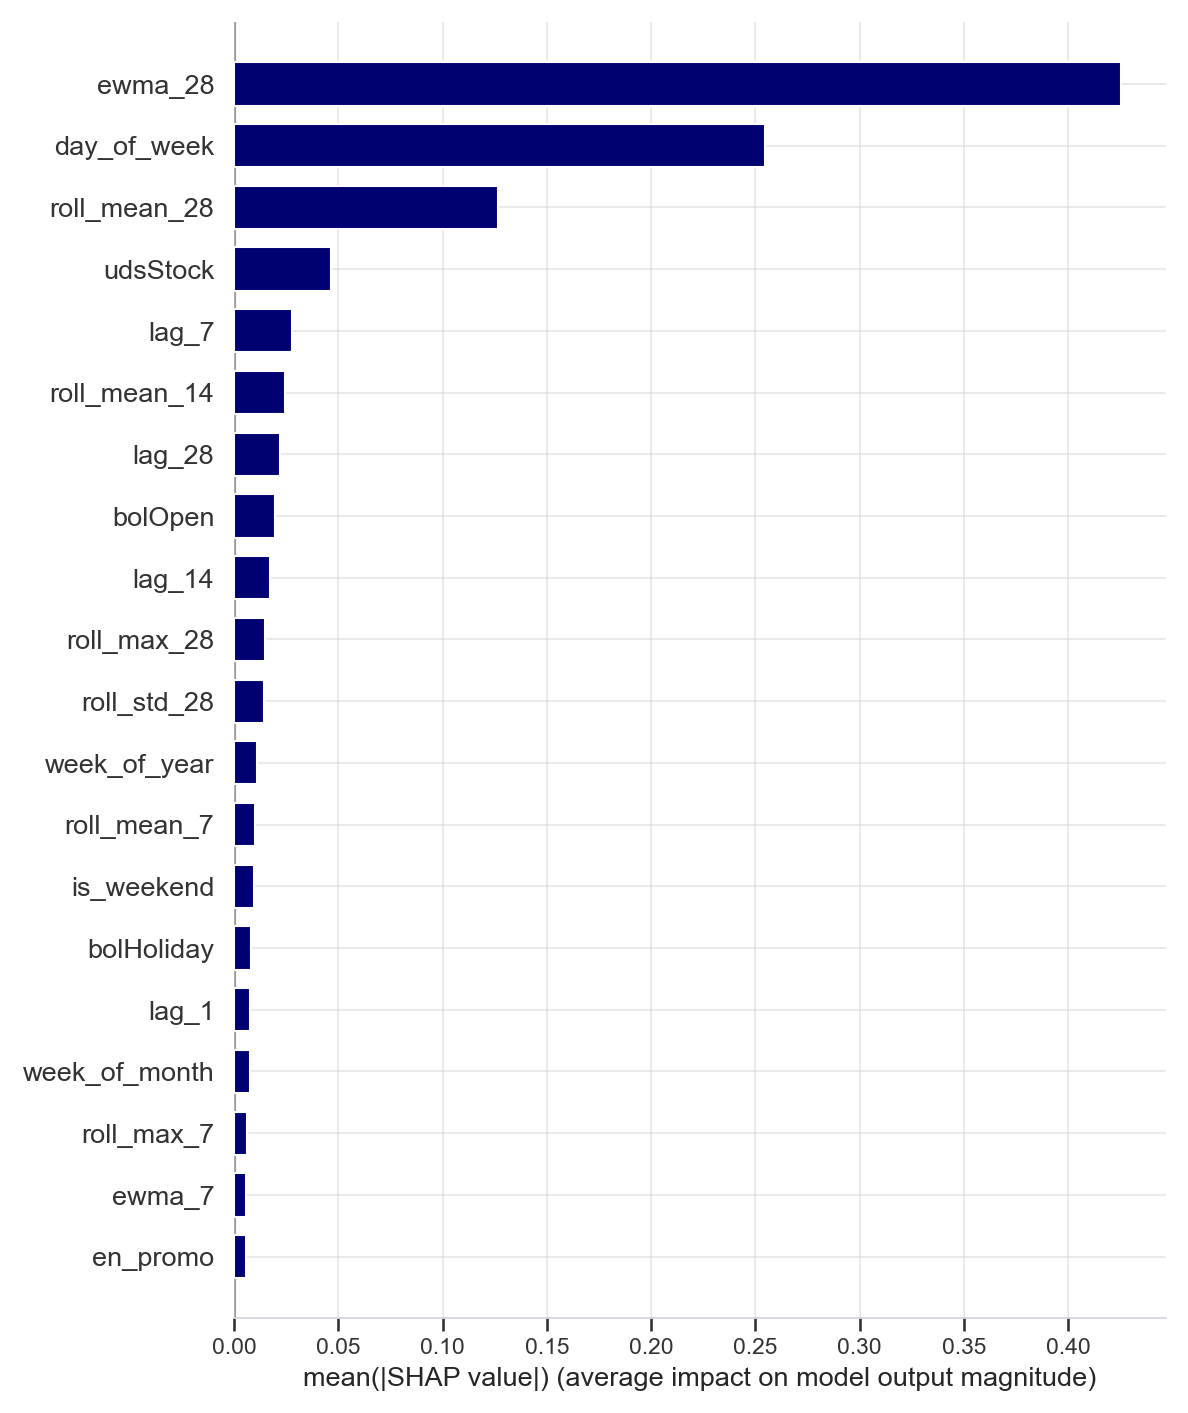

   → Saved 15_shap_bar.png

── Top 15 Features by Mean |SHAP| ──
     feature  mean_abs_shap
     ewma_28       0.425527
 day_of_week       0.254501
roll_mean_28       0.126611
    udsStock       0.046422
       lag_7       0.027812
roll_mean_14       0.024409
      lag_28       0.021943
     bolOpen       0.019347
      lag_14       0.016983
 roll_max_28       0.014632
 roll_std_28       0.014227
week_of_year       0.011014
 roll_mean_7       0.009892
  is_weekend       0.009628
  bolHoliday       0.008233


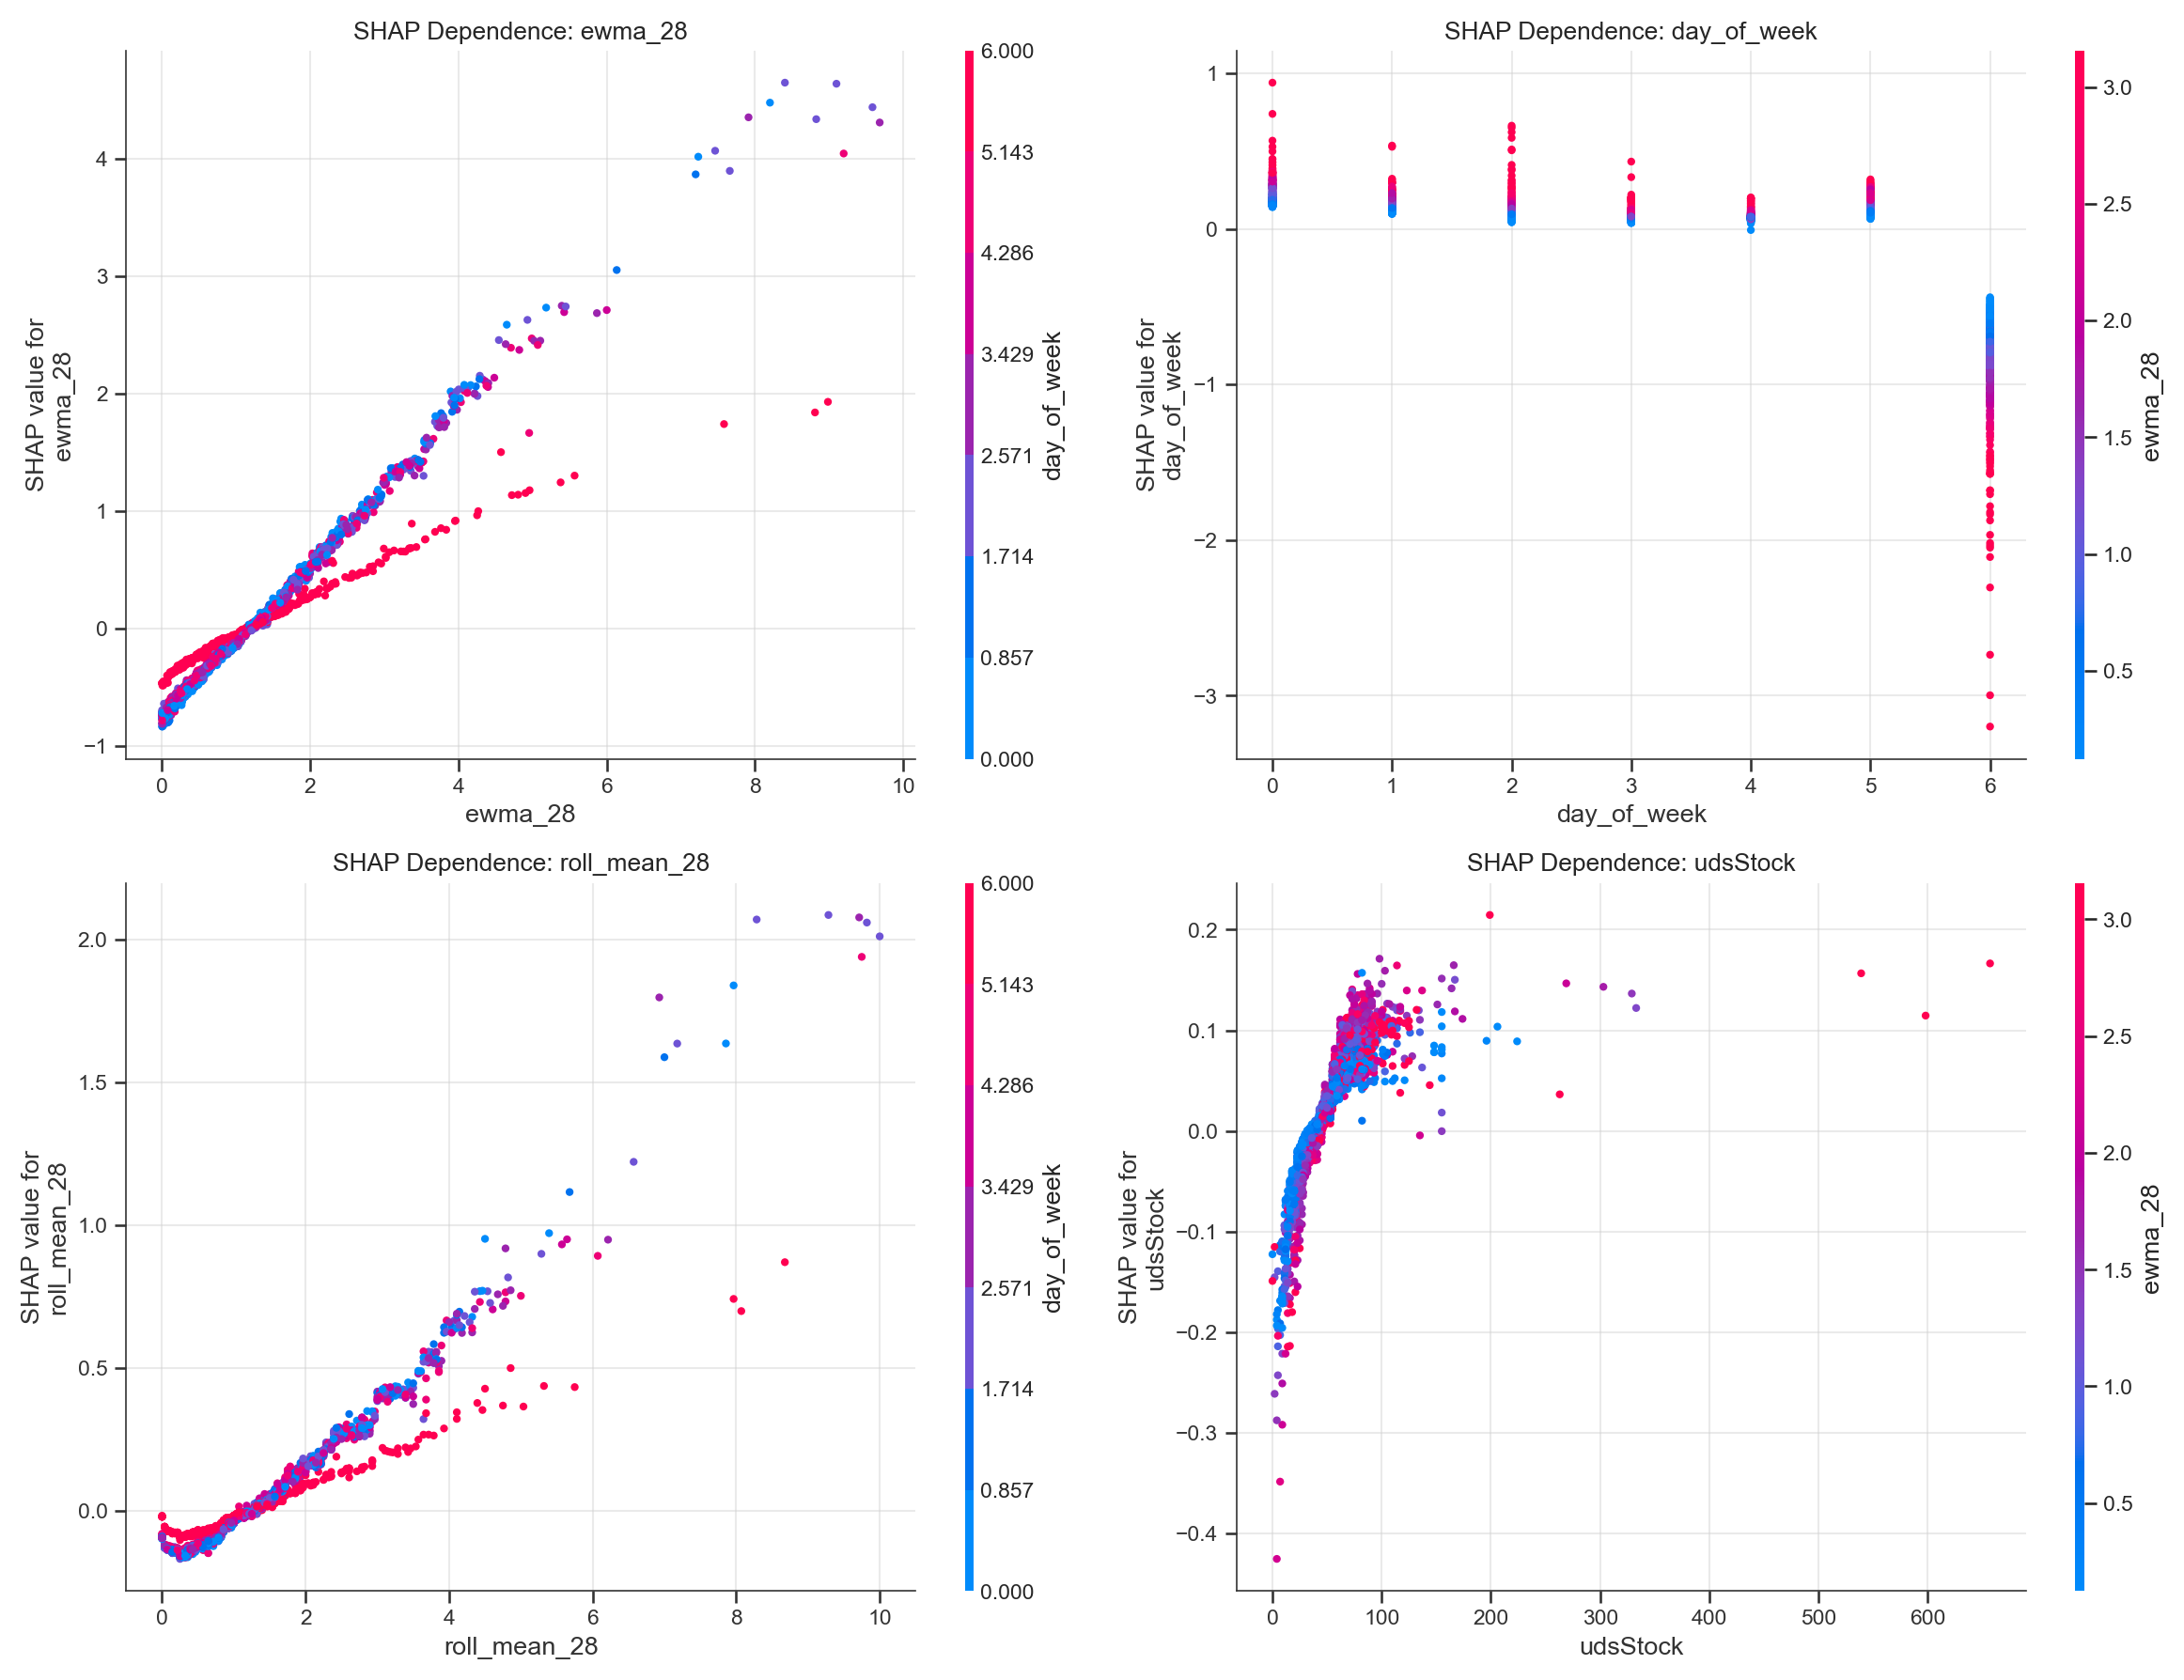

   → Saved 16_shap_dependence_top4.png


In [3]:
print('\n' + '=' * 60)
print('2. SHAP FEATURE IMPORTANCE')
print('=' * 60)

np.random.seed(42)
shap_sample_idx = np.random.choice(len(X_test), size=min(3000, len(X_test)), replace=False)
X_shap = X_test.iloc[shap_sample_idx]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

# 2.1 SHAP summary (beeswarm)
print('Generating SHAP summary plot...')
fig, ax = plt.subplots(figsize=(12, 10))
shap.summary_plot(shap_values, X_shap, show=False, max_display=20)
save_fig('14_shap_summary')

# 2.2 SHAP bar plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False, max_display=20,
                  color=PRIMARY)
save_fig('15_shap_bar')

# 2.3 SHAP values table
shap_importance = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print('\n\u2500\u2500 Top 15 Features by Mean |SHAP| \u2500\u2500')
print(shap_importance.head(15).to_string(index=False))
shap_importance.to_csv(OUTPUT_DIR / 'shap_importance.csv', index=False)

# 2.4 SHAP dependence plots for top 4 features
top4 = shap_importance['feature'].head(4).tolist()
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, feat in zip(axes.flat, top4):
    shap.dependence_plot(feat, shap_values, X_shap, ax=ax, show=False)
    ax.set_title(f'SHAP Dependence: {feat}')
save_fig('16_shap_dependence_top4')


## 3. Error Analysis

Error distributions per model, per-product RMSE distributions,
products with most/least improvement over naive, and error by day of week.



3. ERROR ANALYSIS


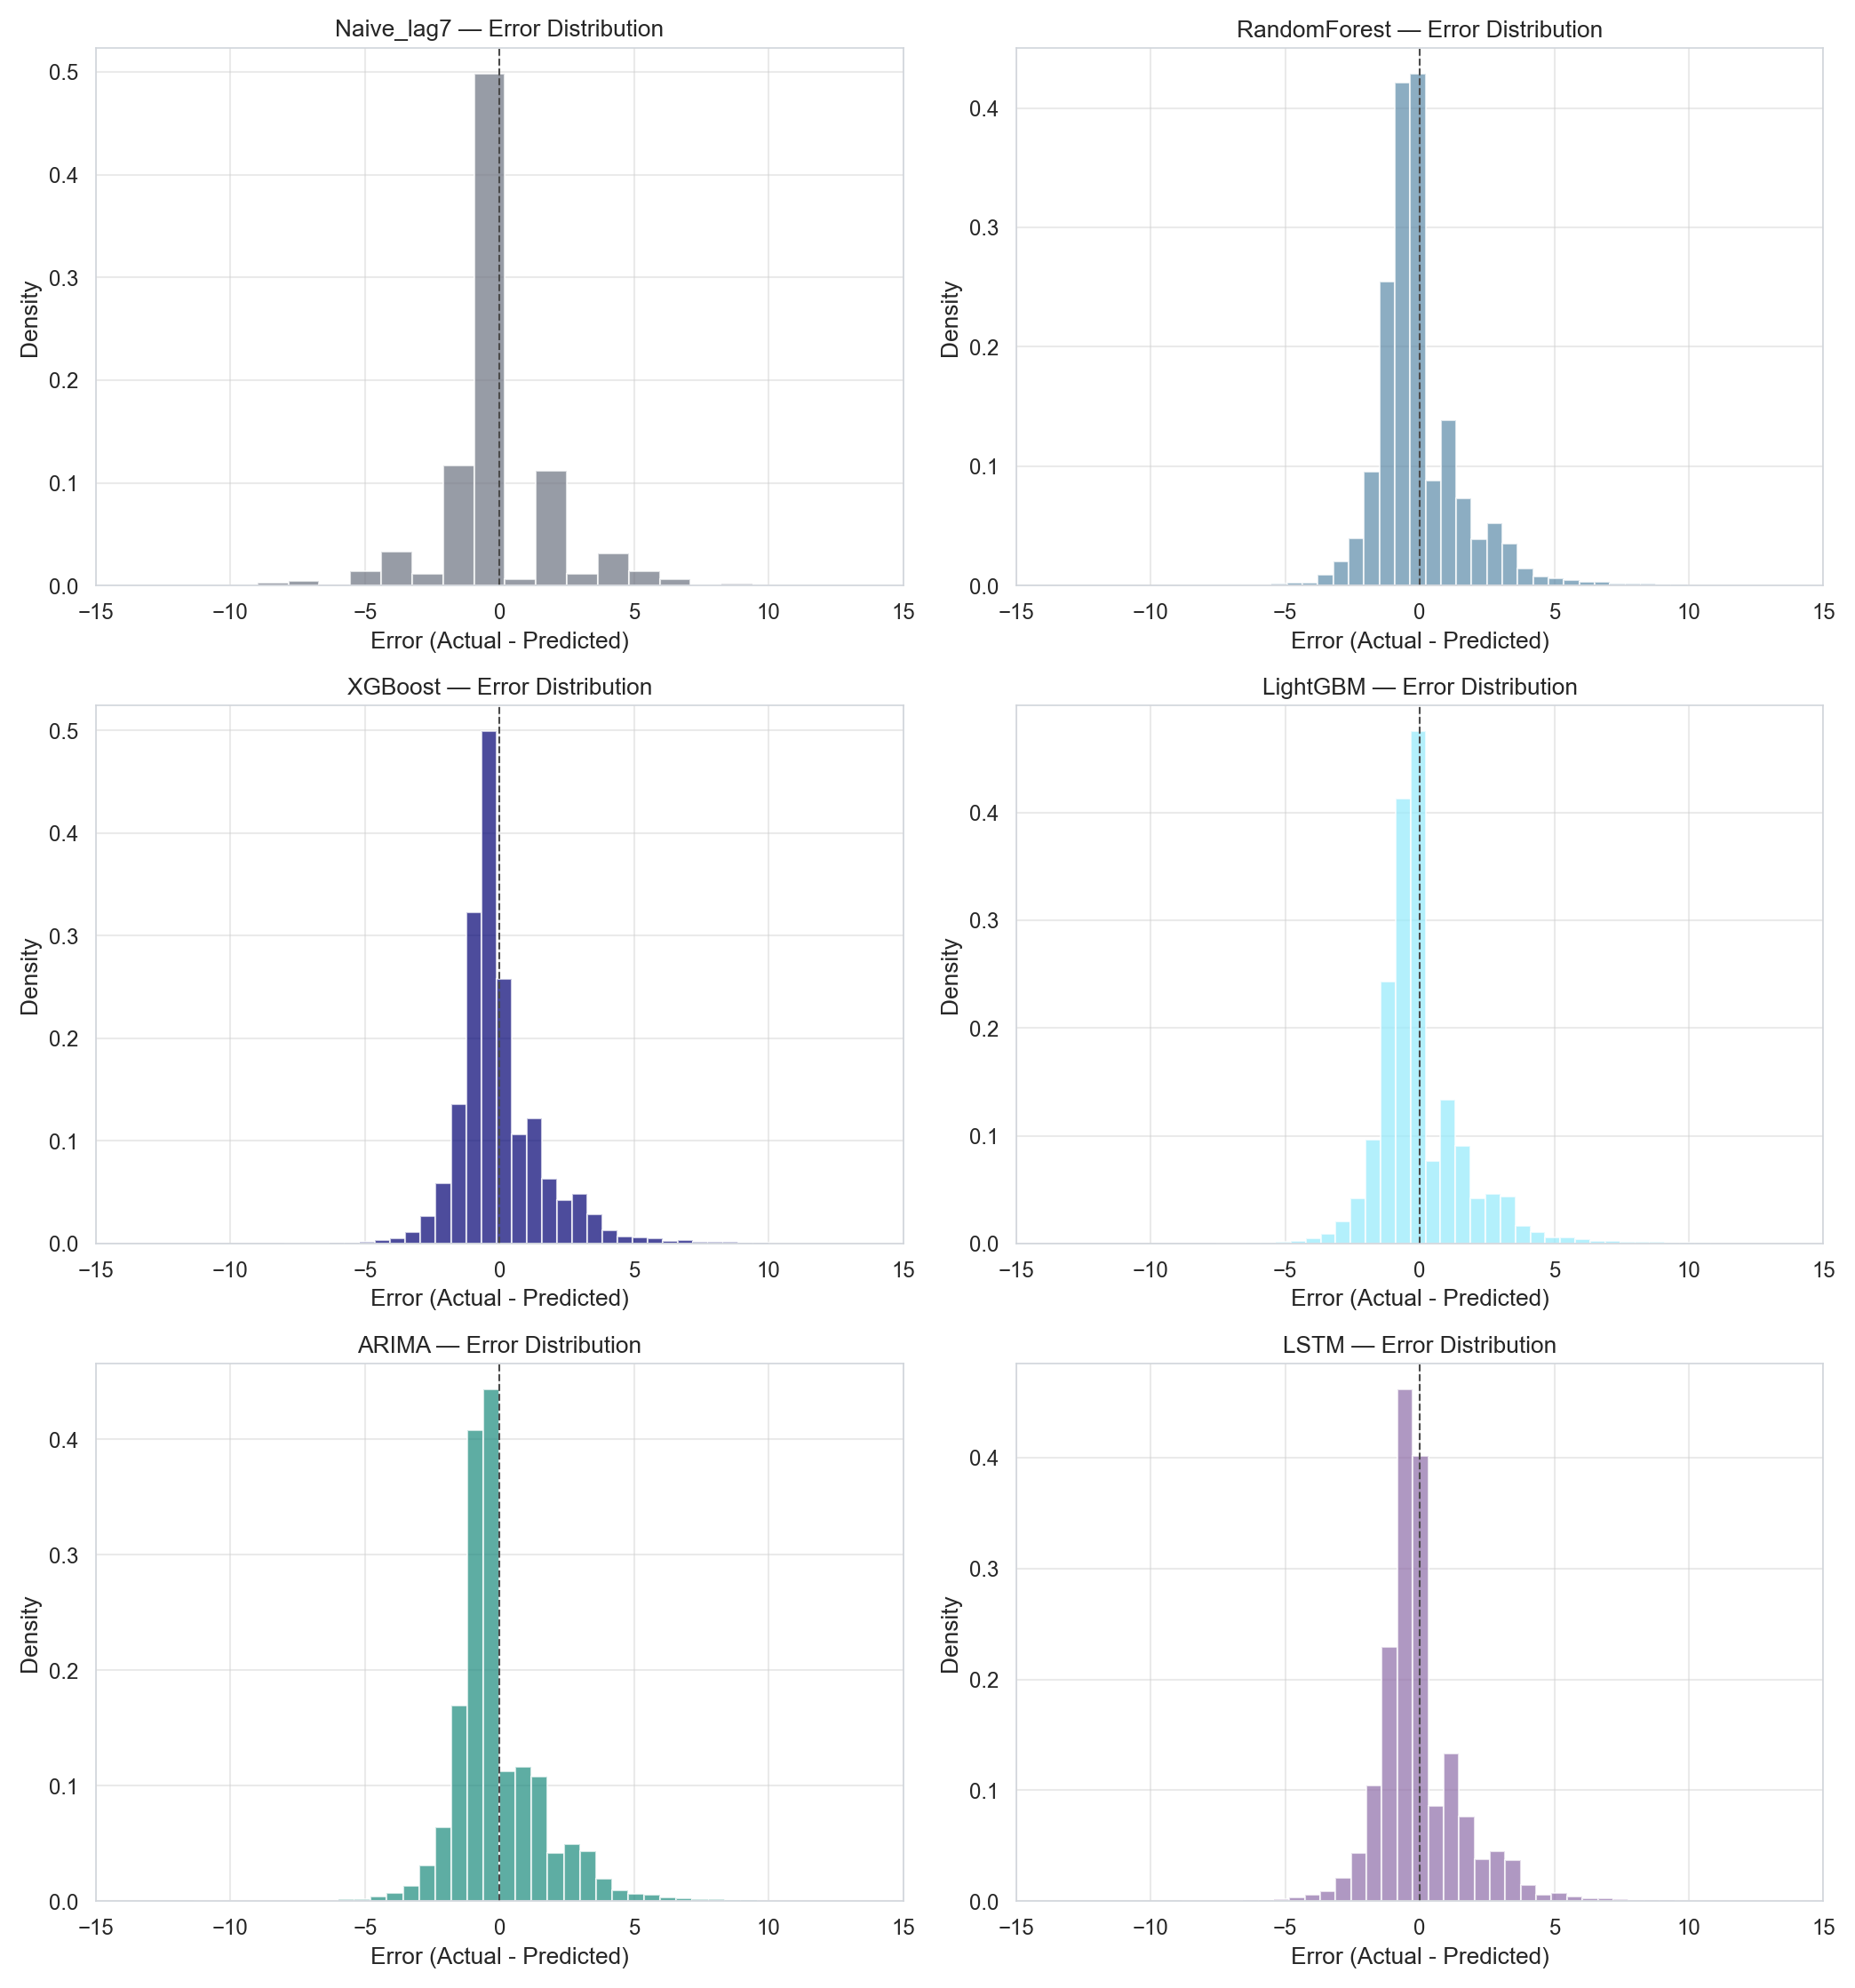

   → Saved 17_error_distributions.png

Per-product RMSE distribution:


       Naive_lag7  RandomForest  XGBoost  LightGBM    ARIMA     LSTM
count     861.000       861.000  861.000   861.000  861.000  861.000
mean        2.006         1.452    1.453     1.459    1.531    1.462
std         1.078         0.752    0.747     0.753    0.814    0.751
min         0.000         0.023    0.010     0.009    0.000    0.144
25%         1.317         1.007    1.000     1.012    1.029    0.984
50%         1.826         1.316    1.329     1.332    1.371    1.340
75%         2.463         1.751    1.750     1.776    1.853    1.774
max        10.141         6.732    6.761     6.753    6.677    6.788


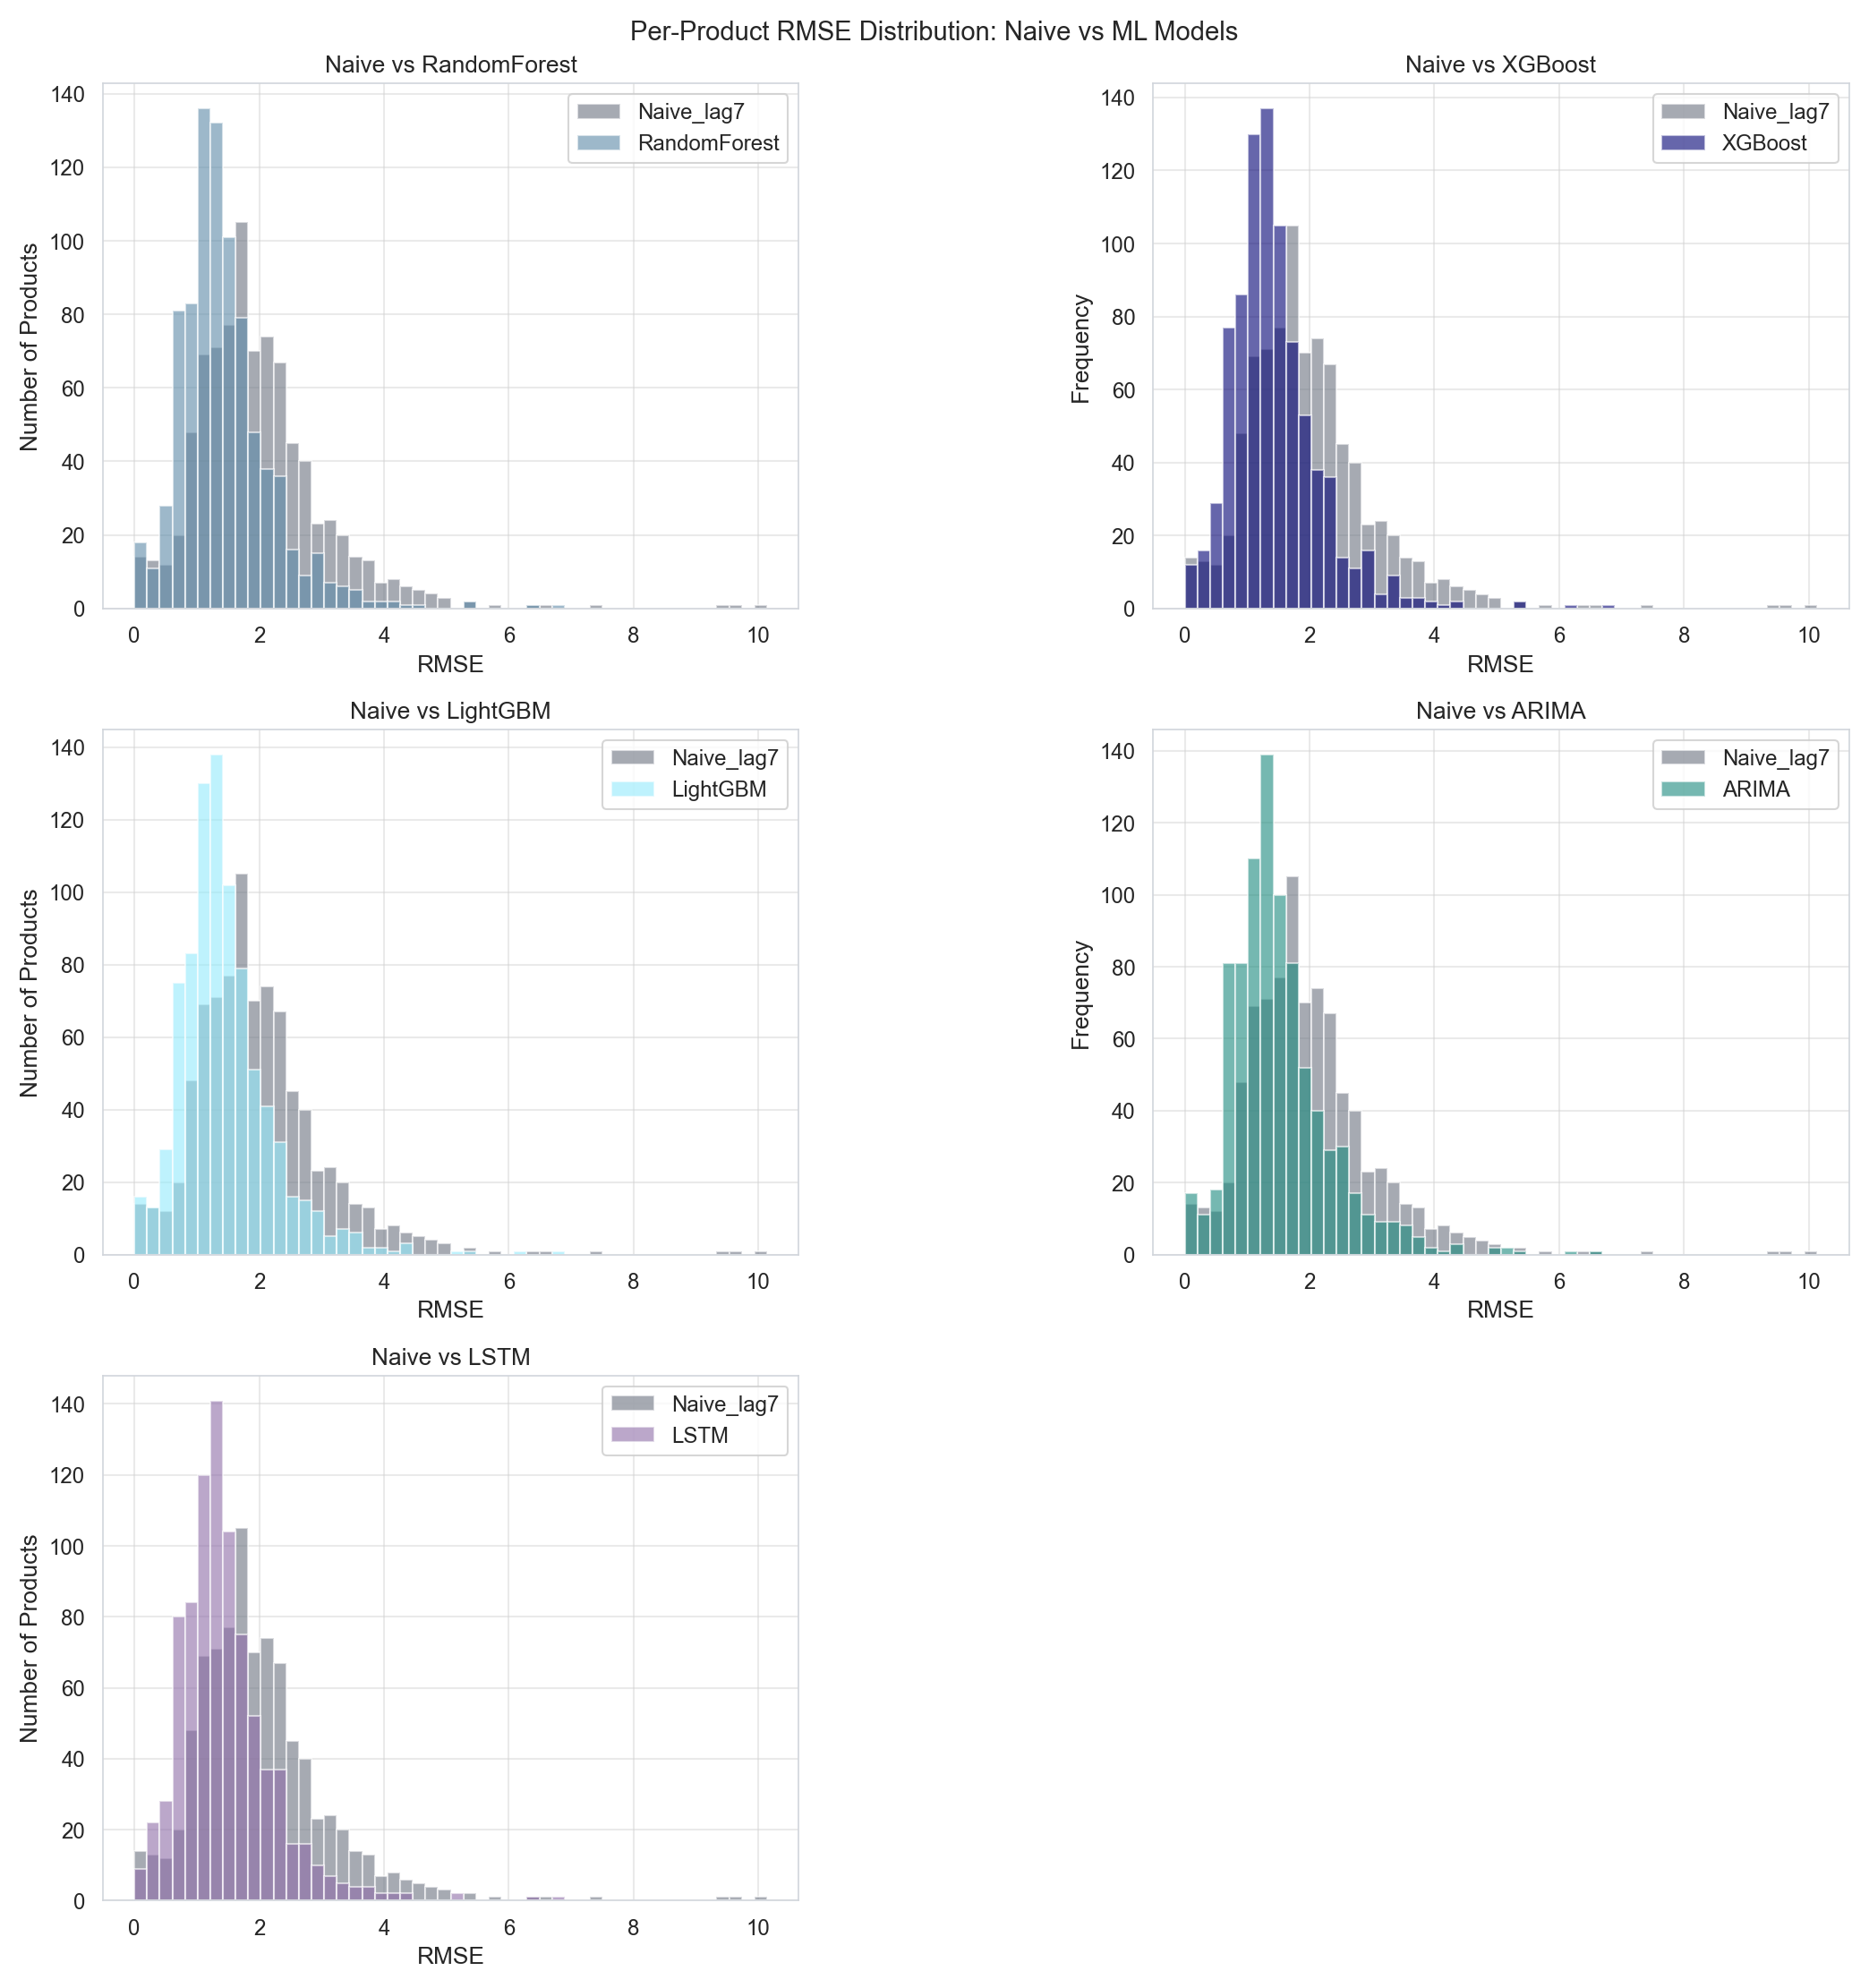

   → Saved 18_per_product_rmse_dist.png

── Top 10 products with most improvement (Naive→LightGBM) ──
producto
359    9.001
21     3.138
228    2.801
2      2.385
669    2.193
78     2.076
97     1.889
70     1.769
136    1.747
68     1.672
dtype: float64

── 10 products with least improvement ──
producto
929   -0.076
951   -0.078
708   -0.083
758   -0.132
593   -0.140
177   -0.153
521   -0.176
741   -0.188
401   -0.226
13    -0.646
dtype: float64


In [4]:
print('\n' + '=' * 60)
print('3. ERROR ANALYSIS')
print('=' * 60)

pf = preds.copy()
models = ['Naive_lag7', 'RandomForest', 'XGBoost', 'LightGBM', 'ARIMA', 'LSTM']

# 3.1 Error distribution per model
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
for ax, m in zip(axes.flat, models):
    errors = pf[TARGET] - pf[m]
    ax.hist(errors, bins=80, edgecolor='white', alpha=0.7, density=True, color=get_model_color(m))
    ax.axvline(x=0, color=ALERT, linewidth=1, linestyle='--')
    ax.set_title(f'{m} \u2014 Error Distribution')
    ax.set_xlabel('Error (Actual - Predicted)')
    ax.set_ylabel('Density')
    ax.set_xlim(-15, 15)
save_fig('17_error_distributions')

# 3.2 Per-product RMSE distribution
print('\nPer-product RMSE distribution:')
prod_rmse = {}
for m in models:
    per_prod = pf.groupby('producto').apply(
        lambda g: np.sqrt(mean_squared_error(g[TARGET], g[m])), include_groups=False
    )
    prod_rmse[m] = per_prod

prod_rmse_df = pd.DataFrame(prod_rmse)
print(prod_rmse_df.describe().round(3))

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
ml_models = ['RandomForest', 'XGBoost', 'LightGBM', 'ARIMA', 'LSTM']
ml_colors = [get_model_color(m) for m in ml_models]
for ax, ml_model, ml_color in zip(axes.flat[:5], ml_models, ml_colors):
    prod_rmse_df[['Naive_lag7', ml_model]].plot(
        kind='hist', bins=50, alpha=0.6, ax=ax, edgecolor='white',
        color=[get_model_color('Naive_lag7'), ml_color]
    )
    ax.set_title(f'Naive vs {ml_model}')
    ax.set_xlabel('RMSE')
axes.flat[0].set_ylabel('Number of Products')
axes.flat[2].set_ylabel('Number of Products')
axes.flat[4].set_ylabel('Number of Products')
# Center the last panel (LSTM) by hiding the 6th and shifting
axes.flat[5].set_visible(False)
axes.flat[4].set_position([0.3, axes.flat[4].get_position().y0, axes.flat[4].get_position().width, axes.flat[4].get_position().height])
plt.suptitle('Per-Product RMSE Distribution: Naive vs ML Models', fontsize=14)
save_fig('18_per_product_rmse_dist')

# 3.3 Products where ML improves most / least
improvement = prod_rmse_df['Naive_lag7'] - prod_rmse_df['LightGBM']
improvement = improvement.sort_values(ascending=False)
print(f'\n\u2500\u2500 Top 10 products with most improvement (Naive\u2192LightGBM) \u2500\u2500')
print(improvement.head(10).round(3))
print(f'\n\u2500\u2500 10 products with least improvement \u2500\u2500')
print(improvement.tail(10).round(3))


### Error by Day of Week & Promo vs Non-Promo Comparison


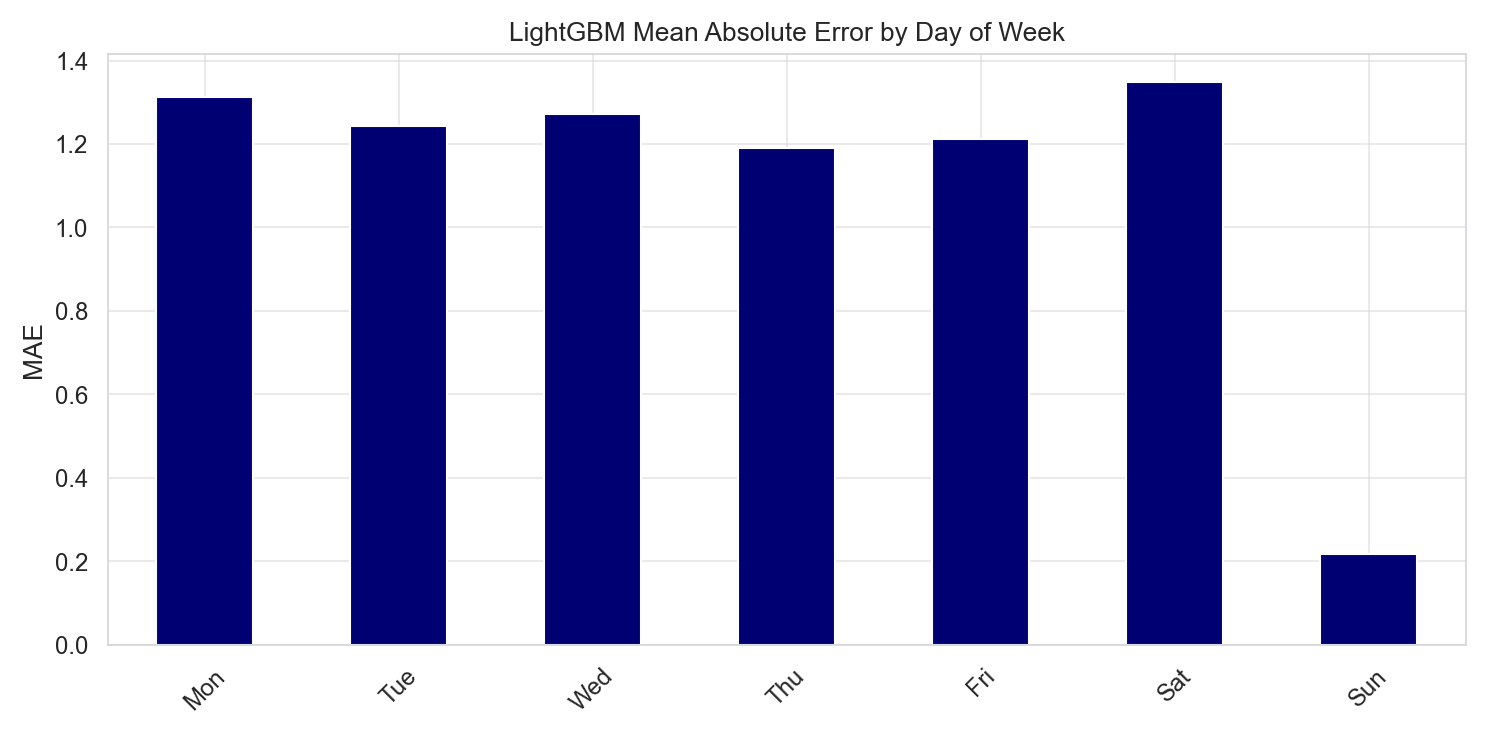

   → Saved 19_mae_by_day_of_week.png

── Detailed Promo vs Non-Promo Metrics ──


                          MAE    MAPE   RMSE  sigma_e
segment   model                                      
Non-Promo ARIMA         1.195  54.049  1.732    1.729
          LSTM          1.076  52.936  1.649    1.649
          LightGBM      1.066  52.867  1.644    1.644
          Naive_lag7    1.237  74.213  2.288    2.288
          RandomForest  1.088  50.082  1.642    1.641
          XGBoost       1.070  52.117  1.640    1.639
Overall   ARIMA         1.211  53.874  1.734    1.732
          LSTM          1.089  52.877  1.643    1.643
          LightGBM      1.092  51.781  1.641    1.641
          Naive_lag7    1.256  74.359  2.277    2.277
          RandomForest  1.102  49.888  1.635    1.635
          XGBoost       1.090  51.317  1.634    1.634
Promo     ARIMA         1.271  53.278  1.740    1.739
          LSTM          1.135  52.675  1.622    1.620
          LightGBM      1.184  48.091  1.631    1.629
          Naive_lag7    1.326  74.856  2.233    2.233
          RandomForest  1.15

In [5]:
# 3.4 Error by day of week
pf_with_dow = pf.merge(
    df[['producto', 'fecha', 'day_of_week']].drop_duplicates(),
    on=['producto', 'fecha'], how='left'
)

dow_errors = {}
for m in ['LightGBM']:
    pf_with_dow['_err'] = np.abs(pf_with_dow[TARGET] - pf_with_dow[m])
    dow_errors[m] = pf_with_dow.groupby('day_of_week')['_err'].mean()

dow_df = pd.DataFrame(dow_errors)
dow_df.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(10, 5))
dow_df.plot(kind='bar', ax=ax, color=PRIMARY, edgecolor='white', legend=False)
ax.set_title('LightGBM Mean Absolute Error by Day of Week')
ax.set_ylabel('MAE')
ax.set_xlabel('')
plt.xticks(rotation=45)
save_fig('19_mae_by_day_of_week')

# 3.5 Promo vs Non-Promo detailed comparison
print('\n\u2500\u2500 Detailed Promo vs Non-Promo Metrics \u2500\u2500')
comparison_rows = []
for label, mask in [('Overall', pf[TARGET] >= 0), ('Non-Promo', pf['en_promo'] == 0), ('Promo', pf['en_promo'] == 1)]:
    subset = pf[mask]
    for m in models:
        metrics = calc_metrics(subset[TARGET], subset[m])
        metrics['segment'] = label
        metrics['model'] = m
        comparison_rows.append(metrics)

comp_df = pd.DataFrame(comparison_rows)
comp_pivot = comp_df.pivot_table(index=['segment', 'model'], values=['MAE', 'RMSE', 'MAPE', 'sigma_e'])
print(comp_pivot.round(3).to_string())
comp_df.to_csv(OUTPUT_DIR / 'promo_comparison.csv', index=False)

print('\n' + '=' * 60)
print('Done.')
print('=' * 60)


## Documentation

References to the documentation of the main libraries and functions used in this notebook.

1. SHAP (2026). *SHAP: SHapley Additive exPlanations*. https://shap.readthedocs.io/en/latest/
2. SHAP (2026). *shap.TreeExplainer*. https://shap.readthedocs.io/en/latest/generated/shap.TreeExplainer.html
3. LightGBM (2026). *lightgbm.LGBMRegressor*. https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html
